In [7]:
import pandas as pd
import numpy as np

# Set your local dataset path
DATA_PATH = r"C:\Users\HP\Desktop\Quarter-6\Advanced Machine Learning\Project\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\\"

# File paths
FEATURES_PATH = DATA_PATH + "features.txt"
ACTIVITY_LABELS_PATH = DATA_PATH + "activity_labels.txt"
TRAIN_X_PATH = DATA_PATH + "train\\X_train.txt"
TRAIN_Y_PATH = DATA_PATH + "train\\y_train.txt"
TEST_X_PATH = DATA_PATH + "test\\X_test.txt"
TEST_Y_PATH = DATA_PATH + "test\\y_test.txt"

# Load feature names
feature_names_df = pd.read_csv(FEATURES_PATH, sep=r'\s+', header=None, names=["index", "feature"])
feature_names = feature_names_df["feature"].tolist()

# Deduplicate feature names
def deduplicate_columns(columns):
    seen = {}
    new_columns = []
    for col in columns:
        if col not in seen:
            seen[col] = 1
            new_columns.append(col)
        else:
            seen[col] += 1
            new_columns.append(f"{col}_{seen[col]}")
    return new_columns

feature_names_unique = deduplicate_columns(feature_names)

# Load activity labels and create mapping
activity_labels = pd.read_csv(ACTIVITY_LABELS_PATH, sep=r'\s+', header=None, names=["id", "activity"])
activity_map = dict(zip(activity_labels["id"], activity_labels["activity"]))

# Load full data
X_train = pd.read_csv(TRAIN_X_PATH, sep=r'\s+', header=None, names=feature_names_unique)
y_train = pd.read_csv(TRAIN_Y_PATH, header=None, names=["Activity"])
X_test = pd.read_csv(TEST_X_PATH, sep=r'\s+', header=None, names=feature_names_unique)
y_test = pd.read_csv(TEST_Y_PATH, header=None, names=["Activity"])

# Combine train and test sets
X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)
y["Activity"] = y["Activity"].map(activity_map)


# Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to retain 95% variance
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original shape: {X.shape}")
print(f"Reduced shape after PCA: {X_pca.shape}")

# Split the reduced data
from sklearn.model_selection import train_test_split
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# Dataset summary
print("\nDataset loaded and processed successfully!")
print("Full Dataset Shape:", X.shape)
print("Reduced Dataset Shape:", X_pca.shape)
print("Total Samples:", X.shape[0])
print("Total Features (before PCA):", X.shape[1])
print("Total Features (after PCA):", X_pca.shape[1])
print("Number of Activity Classes:", y['Activity'].nunique())
print("\nClass Distribution:\n", y['Activity'].value_counts())

# Print training and testing records (post PCA)
print("\n Dataset Record Counts (after PCA split):")
print(f"Training Features Shape: {X_train_pca.shape}")
print(f"Training Labels Shape  : {y_train_pca.shape}")
print(f"Testing Features Shape : {X_test_pca.shape}")
print(f"Testing Labels Shape   : {y_test_pca.shape}")


 



Original shape: (10299, 561)
Reduced shape after PCA: (10299, 104)

Dataset loaded and processed successfully!
Full Dataset Shape: (10299, 561)
Reduced Dataset Shape: (10299, 104)
Total Samples: 10299
Total Features (before PCA): 561
Total Features (after PCA): 104
Number of Activity Classes: 6

Class Distribution:
 Activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64

 Dataset Record Counts (after PCA split):
Training Features Shape: (7209, 104)
Training Labels Shape  : (7209, 1)
Testing Features Shape : (3090, 104)
Testing Labels Shape   : (3090, 1)


In [23]:
# Check for missing values in the dataset
print("\nTotal Missing Values in Dataset:", X.isnull().sum().sum())



Total Missing Values in Dataset: 0


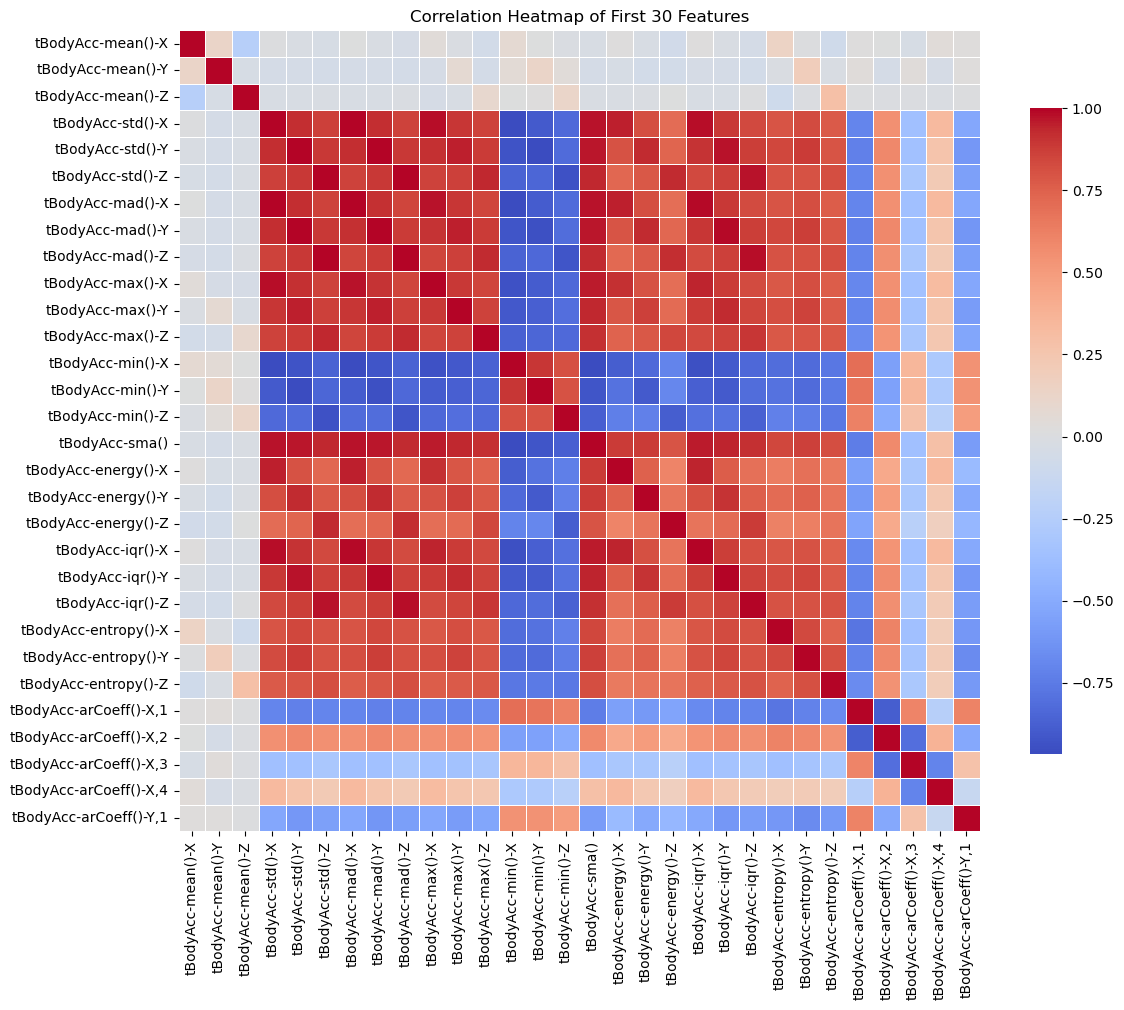

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix for the first N features (to avoid memory overload)
N = 30  # change this to view more or fewer features
corr_subset = X.iloc[:, :N].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_subset, annot=False, cmap='coolwarm', fmt=".2f", square=True,
            cbar_kws={'shrink': .8}, linewidths=.5)
plt.title("Correlation Heatmap of First 30 Features")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [21]:
# Drop one feature from each pair of highly correlated features (> 0.95)
corr_matrix = pd.DataFrame(X).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

X_reduced = X.drop(columns=to_drop)

print(f"\nOriginal Features: {X.shape[1]}")
print(f"Reduced Features (after removing correlated): {X_reduced.shape[1]}")



Original Features: 561
Reduced Features (after removing correlated): 253



=== Random Forest Performance (PCA Data) ===
Accuracy : 0.9424
F1 Score : 0.9422


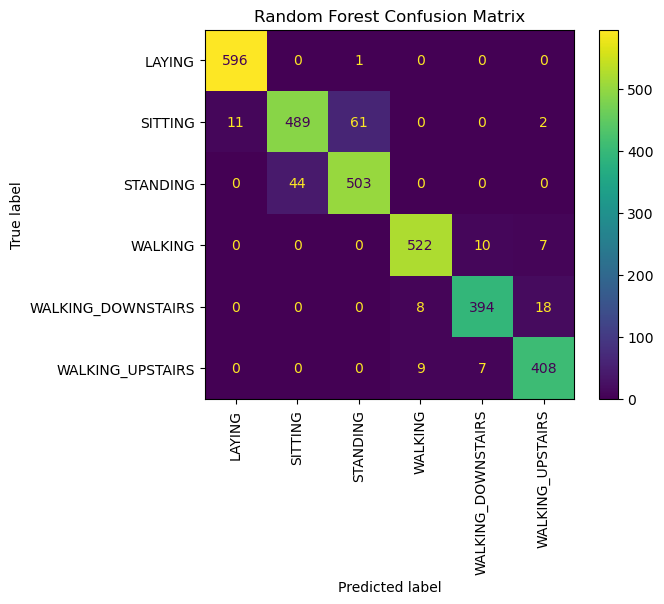

In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Train Random Forest on PCA-reduced data
rf_pca = RandomForestClassifier(random_state=42)
rf_pca.fit(X_train_pca, y_train_pca.values.ravel())


# Predict and evaluate
y_pred_pca = rf_pca.predict(X_test_pca)

# Accuracy and F1-score
accuracy = accuracy_score(y_test_pca, y_pred_pca)
f1 = f1_score(y_test_pca, y_pred_pca, average='weighted')

print("\n=== Random Forest Performance (PCA Data) ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"F1 Score : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_pca, y_pred_pca, labels=rf_pca.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_pca.classes_)
disp.plot(xticks_rotation='vertical')
plt.title("Random Forest Confusion Matrix")
plt.show()


=== SVM Performance (PCA Data) ===
Accuracy : 0.9696
F1 Score : 0.9695


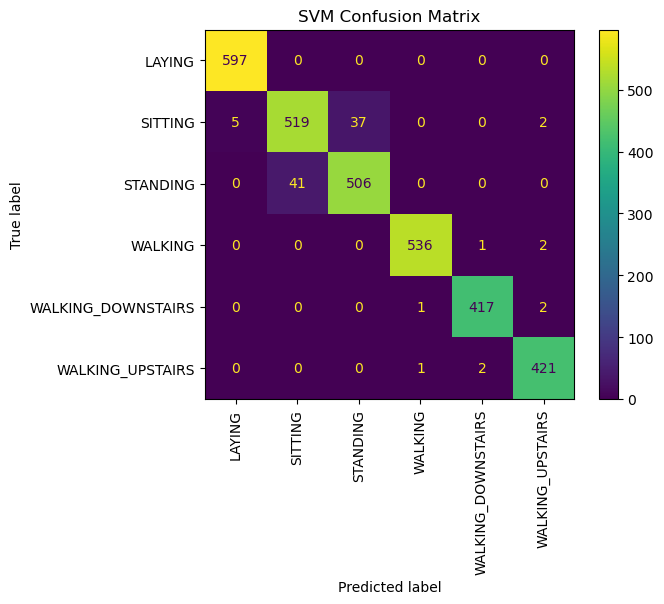

In [80]:
from sklearn.svm import SVC

# Train SVM on PCA-reduced data
svm_pca = SVC(kernel='rbf', random_state=42)
svm_pca.fit(X_train_pca, y_train_pca.values.ravel())

# Predict and evaluate
y_pred_svm = svm_pca.predict(X_test_pca)

accuracy_svm = accuracy_score(y_test_pca, y_pred_svm)
f1_svm = f1_score(y_test_pca, y_pred_svm, average='weighted')

print("\n=== SVM Performance (PCA Data) ===")
print(f"Accuracy : {accuracy_svm:.4f}")
print(f"F1 Score : {f1_svm:.4f}")

# Confusion Matrix Plot
cm_svm = confusion_matrix(y_test_pca, y_pred_svm, labels=svm.classes_)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm.classes_)
disp_svm.plot(xticks_rotation='vertical')
plt.title("SVM Confusion Matrix")
plt.show()




=== MLP Performance (PCA Data) ===
Accuracy : 0.9748
F1 Score : 0.9747


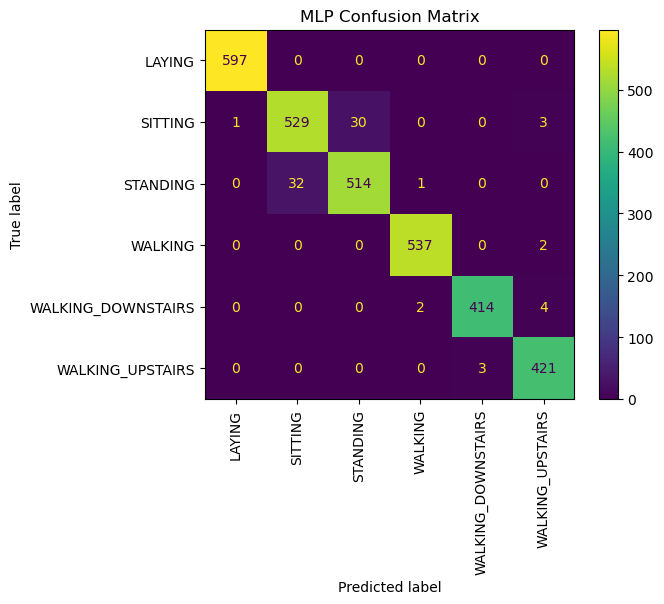

In [68]:
from sklearn.neural_network import MLPClassifier

# Train MLP on PCA-reduced data
mlp_pca = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp_pca.fit(X_train_pca, y_train_pca.values.ravel())

# Predict and evaluate
y_pred_mlp = mlp_pca.predict(X_test_pca)

accuracy_mlp = accuracy_score(y_test_pca, y_pred_mlp)
f1_mlp = f1_score(y_test_pca, y_pred_mlp, average='weighted')

print("\n=== MLP Performance (PCA Data) ===")
print(f"Accuracy : {accuracy_mlp:.4f}")
print(f"F1 Score : {f1_mlp:.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming y_test_mlp and y_pred_mlp are your test labels and predictions
cm_mlp = confusion_matrix(y_test_pca, y_pred_mlp, labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=mlp.classes_)
disp.plot(xticks_rotation='vertical')
plt.title("MLP Confusion Matrix")
plt.show()




In [33]:
# Summary Table
print("\n=== Model Performance Summary (PCA) ===")
print(f"{'Model':<20} {'Accuracy':<10} {'F1 Score'}")
print(f"{'Random Forest':<20} {accuracy:.4f}     {f1:.4f}")
print(f"{'SVM':<20} {accuracy_svm:.4f}     {f1_svm:.4f}")
print(f"{'MLP':<20} {accuracy_mlp:.4f}     {f1_mlp:.4f}")



=== Model Performance Summary (PCA) ===
Model                Accuracy   F1 Score
Random Forest        0.9424     0.9422
SVM                  0.9696     0.9695
MLP                  0.9748     0.9747


In [35]:
# --- Split Time vs. Frequency Domain Features ---
time_cols = [col for col in X.columns if col.startswith('t')]
freq_cols = [col for col in X.columns if col.startswith('f')]

X_time = X[time_cols]
X_freq = X[freq_cols]

# Standardize each separately
scaler_time = StandardScaler()
X_time_scaled = scaler_time.fit_transform(X_time)

scaler_freq = StandardScaler()
X_freq_scaled = scaler_freq.fit_transform(X_freq)

# Apply PCA to both (retain 95% variance)
pca_time = PCA(n_components=0.95)
X_time_pca = pca_time.fit_transform(X_time_scaled)

pca_freq = PCA(n_components=0.95)
X_freq_pca = pca_freq.fit_transform(X_freq_scaled)

# Split both into train/test
X_time_train, X_time_test, y_time_train, y_time_test = train_test_split(X_time_pca, y, test_size=0.3, random_state=42)
X_freq_train, X_freq_test, y_freq_train, y_freq_test = train_test_split(X_freq_pca, y, test_size=0.3, random_state=42)

# Train Random Forest on time-domain
rf_time = RandomForestClassifier(random_state=42)
rf_time.fit(X_time_train, y_time_train.values.ravel())
y_pred_time = rf_time.predict(X_time_test)
acc_time = accuracy_score(y_time_test, y_pred_time)
f1_time = f1_score(y_time_test, y_pred_time, average='weighted')

# Train Random Forest on frequency-domain
rf_freq = RandomForestClassifier(random_state=42)
rf_freq.fit(X_freq_train, y_freq_train.values.ravel())
y_pred_freq = rf_freq.predict(X_freq_test)
acc_freq = accuracy_score(y_freq_test, y_pred_freq)
f1_freq = f1_score(y_freq_test, y_pred_freq, average='weighted')

# Print comparison
print("\n=== Time vs Frequency Domain Performance ===")
print(f"{'Domain':<15} {'Accuracy':<10} {'F1 Score'}")
print(f"{'Time Domain':<15} {acc_time:.4f}     {f1_time:.4f}")
print(f"{'Freq Domain':<15} {acc_freq:.4f}     {f1_freq:.4f}")




=== Time vs Frequency Domain Performance ===
Domain          Accuracy   F1 Score
Time Domain     0.9233     0.9228
Freq Domain     0.8133     0.8111


In [2]:
pip install pandas numpy scikit-learn matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# path
base_path = r"C:/Users/HP/Desktop/Quarter-6/Advanced Machine Learning/Project/human+activity+recognition+using+smartphones/UCI HAR Dataset/UCI HAR Dataset/"

# Load features and make them unique
features = pd.read_csv(base_path + 'features.txt', sep=r'\s+', header=None, engine='python')
feature_names = pd.Index(features[1]).astype(str) + '_' + features[0].astype(str)

# Load activity labels
activity_labels = pd.read_csv(base_path + 'activity_labels.txt', sep=r'\s+', header=None, index_col=0, engine='python')[1].to_dict()

# Load training data
X_train = pd.read_csv(base_path + 'train/X_train.txt', sep=r'\s+', header=None, names=feature_names, engine='python')
y_train = pd.read_csv(base_path + 'train/y_train.txt', header=None, names=['Activity'])
y_train['Activity'] = y_train['Activity'].map(activity_labels)

# Load testing data
X_test = pd.read_csv(base_path + 'test/X_test.txt', sep=r'\s+', header=None, names=feature_names, engine='python')
y_test = pd.read_csv(base_path + 'test/y_test.txt', header=None, names=['Activity'])
y_test['Activity'] = y_test['Activity'].map(activity_labels)


In [39]:
features = pd.read_csv(base_path + 'features.txt', sep=r'\s+', header=None, engine='python')
feature_names = pd.Index(features[1]).astype(str) + '_' + features[0].astype(str)  # Ensured uniqueness


In [41]:
activity_labels = pd.read_csv(base_path + 'activity_labels.txt', sep=r'\s+', header=None, index_col=0, engine='python')[1].to_dict()


In [43]:
X_train = pd.read_csv(base_path + 'train/X_train.txt', sep=r'\s+', header=None, names=feature_names, engine='python')
y_train = pd.read_csv(base_path + 'train/y_train.txt', header=None, names=['Activity'])
y_train['Activity'] = y_train['Activity'].map(activity_labels)

X_test = pd.read_csv(base_path + 'test/X_test.txt', sep=r'\s+', header=None, names=feature_names, engine='python')
y_test = pd.read_csv(base_path + 'test/y_test.txt', header=None, names=['Activity'])
y_test['Activity'] = y_test['Activity'].map(activity_labels)


In [44]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Only transform the test data
X_test_scaled = scaler.transform(X_test)


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Results:

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.89      0.90       491
          STANDING       0.90      0.92      0.91       532
           WALKING       0.90      0.97      0.93       496
WALKING_DOWNSTAIRS       0.96      0.86      0.91       420
  WALKING_UPSTAIRS       0.90      0.92      0.91       471

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



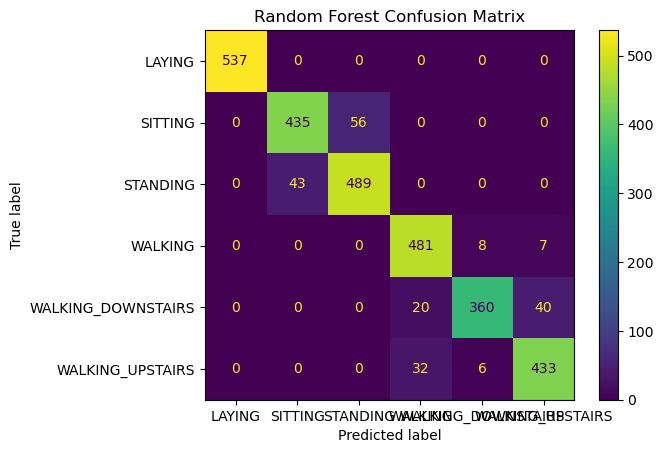

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Train the model
rf = RandomForestClassifier(n_estimators=230, random_state=42)
rf.fit(X_train_scaled, y_train)

# Predict
y_pred_rf = rf.predict(X_test_scaled)

# Evaluate
print("Random Forest Results:\n")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()


Linear SVM Results:

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.96      0.88      0.92       491
          STANDING       0.90      0.97      0.93       532
           WALKING       0.96      1.00      0.98       496
WALKING_DOWNSTAIRS       0.99      0.95      0.97       420
  WALKING_UPSTAIRS       0.97      0.96      0.96       471

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



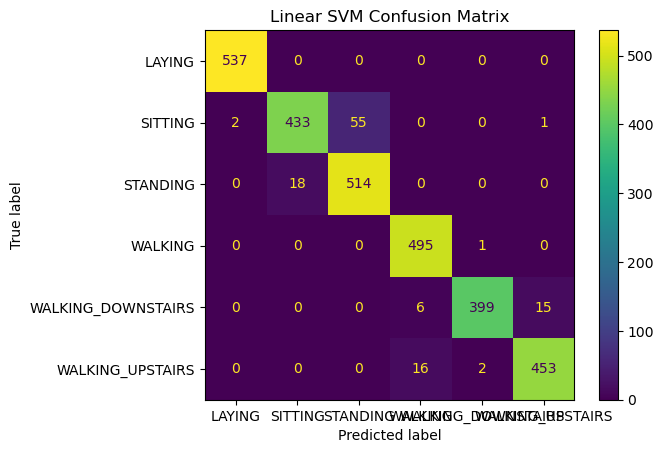

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay



# Linear SVM
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train.values.ravel())
y_pred_svm_linear = svm_linear.predict(X_test_scaled)

print("Linear SVM Results:\n")
print(classification_report(y_test, y_pred_svm_linear))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm_linear)
plt.title("Linear SVM Confusion Matrix")
plt.show()


In [51]:
from sklearn.svm import SVC

# Train
svm = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm.fit(X_train_scaled, y_train)

# Predict
y_pred_svm = svm.predict(X_test_scaled)

# Evaluate
print(" SVM Results:\n")
print(classification_report(y_test, y_pred_svm))


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


 SVM Results:

                    precision    recall  f1-score   support

            LAYING       0.99      1.00      1.00       537
           SITTING       0.94      0.90      0.92       491
          STANDING       0.92      0.95      0.93       532
           WALKING       0.96      0.97      0.97       496
WALKING_DOWNSTAIRS       0.98      0.92      0.95       420
  WALKING_UPSTAIRS       0.93      0.97      0.95       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



Dropped 308 highly correlated features. New feature count: 253
Random Forest (Reduced Features) Results:

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.95      0.91      0.93       491
          STANDING       0.92      0.95      0.94       532
           WALKING       0.93      0.99      0.96       496
WALKING_DOWNSTAIRS       0.97      0.89      0.92       420
  WALKING_UPSTAIRS       0.91      0.92      0.91       471

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



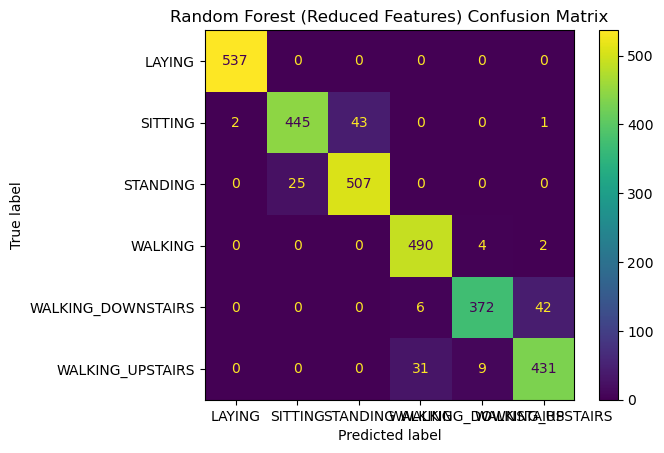

In [53]:
import seaborn as sns

# Compute correlation matrix
cor_matrix = pd.DataFrame(X_train_scaled, columns=feature_names).corr().abs()

# Select upper triangle of correlation matrix
upper = cor_matrix.where(np.triu(np.ones(cor_matrix.shape), k=1).astype(bool))

# Find features with correlation > 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

# Drop highly correlated features
X_train_reduced = pd.DataFrame(X_train_scaled, columns=feature_names).drop(columns=to_drop)
X_test_reduced = pd.DataFrame(X_test_scaled, columns=feature_names).drop(columns=to_drop)

print(f"Dropped {len(to_drop)} highly correlated features. New feature count: {X_train_reduced.shape[1]}")

# Train RF on reduced features
rf_reduced = RandomForestClassifier(n_estimators=100, random_state=42)
rf_reduced.fit(X_train_reduced, y_train.values.ravel())
y_pred_reduced = rf_reduced.predict(X_test_reduced)

print("Random Forest (Reduced Features) Results:\n")
print(classification_report(y_test, y_pred_reduced))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_reduced)
plt.title("Random Forest (Reduced Features) Confusion Matrix")
plt.show()


In [55]:
from sklearn.neural_network import MLPClassifier

# Train
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp.fit(X_train_scaled, y_train)

# Predict
y_pred_mlp = mlp.predict(X_test_scaled)

# Evaluate
print("MLP Results:\n")
print(classification_report(y_test, y_pred_mlp))


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1105: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLP Results:

                    precision    recall  f1-score   support

            LAYING       1.00      0.96      0.98       537
           SITTING       0.95      0.89      0.92       491
          STANDING       0.88      0.96      0.92       532
           WALKING       0.96      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.93      0.96       420
  WALKING_UPSTAIRS       0.95      0.97      0.96       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



In [57]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict with each model
rf_preds = rf.predict(X_test_scaled)
svm_preds = svm.predict(X_test_scaled)
mlp_preds = mlp.predict(X_test_scaled)

# Accuracy Scores
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("SVM Accuracy:", accuracy_score(y_test, svm_preds))
print("MLP Accuracy:", accuracy_score(y_test, mlp_preds))

# Confusion Matrix
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, rf_preds))
print("\nSVM Confusion Matrix:\n", confusion_matrix(y_test, svm_preds))
print("\nMLP Confusion Matrix:\n", confusion_matrix(y_test, mlp_preds))

# Classification Report
print("\nRandom Forest Classification Report:\n", classification_report(y_test, rf_preds))
print("\nSVM Classification Report:\n", classification_report(y_test, svm_preds))
print("\nMLP Classification Report:\n", classification_report(y_test, mlp_preds))


Random Forest Accuracy: 0.9280624363759755
SVM Accuracy: 0.9518154054971157
MLP Accuracy: 0.9507974211062097

Random Forest Confusion Matrix:
 [[537   0   0   0   0   0]
 [  0 435  56   0   0   0]
 [  0  43 489   0   0   0]
 [  0   0   0 481   8   7]
 [  0   0   0  20 360  40]
 [  0   0   0  32   6 433]]

SVM Confusion Matrix:
 [[537   0   0   0   0   0]
 [  3 441  46   0   0   1]
 [  0  29 503   0   0   0]
 [  0   0   0 482   8   6]
 [  0   0   0   6 386  28]
 [  0   0   0  14   1 456]]

MLP Confusion Matrix:
 [[518   0  19   0   0   0]
 [  1 436  53   0   0   1]
 [  0  21 511   0   0   0]
 [  0   0   0 491   3   2]
 [  0   0   0   8 389  23]
 [  0   0   0  13   1 457]]

Random Forest Classification Report:
                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.89      0.90       491
          STANDING       0.90      0.92      0.91       532
           WALKING       0.90      0.97 

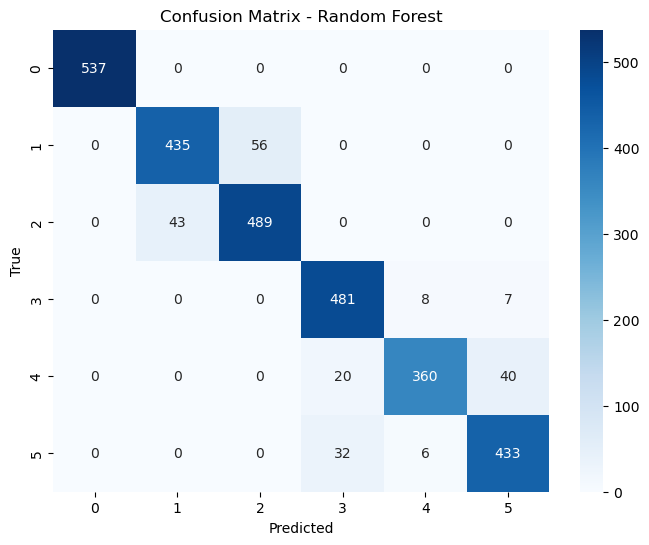

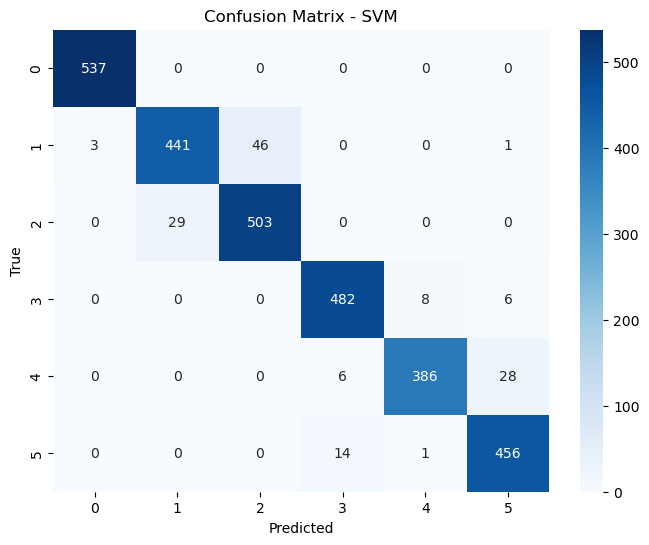

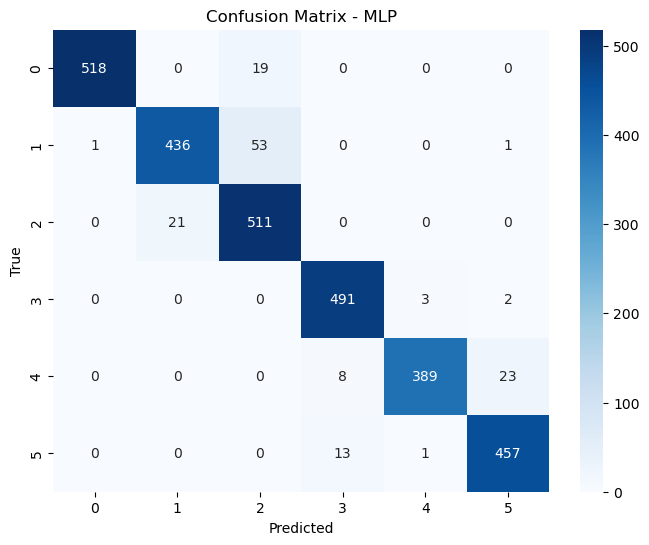

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define function to plot heatmap
def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Plot for each model
plot_conf_matrix(y_test, rf_preds, 'Random Forest')
plot_conf_matrix(y_test, svm_preds, 'SVM')
plot_conf_matrix(y_test, mlp_preds, 'MLP')


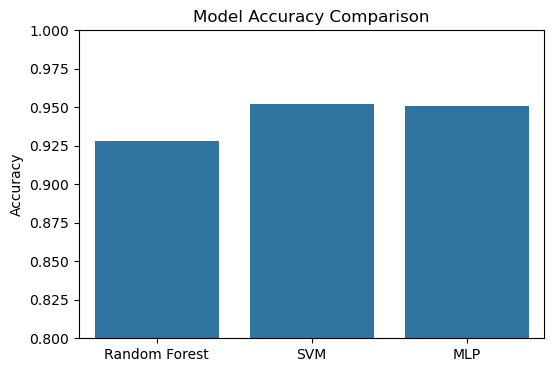

In [61]:
# Accuracy comparison bar chart
model_names = ['Random Forest', 'SVM', 'MLP']
accuracies = [
    accuracy_score(y_test, rf_preds),
    accuracy_score(y_test, svm_preds),
    accuracy_score(y_test, mlp_preds)
]

plt.figure(figsize=(6, 4))
sns.barplot(x=model_names, y=accuracies)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)  # All models perform quite well, so zoom in
plt.show()
